In [1]:

# CUSTOMER CHURN PREDICTION SYSTEM

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [2]:
data = pd.read_csv("C:/Users/akshay/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Display first 5 rows
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [4]:
print("\nDataset Information")
print(data.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [5]:
print("\nShape of Dataset")
print(data.shape)


Shape of Dataset
(7043, 21)


In [6]:
print("\nMissing Values")
print(data.isnull().sum())


Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
print("\nStatistical Summary")
print(data.describe())


Statistical Summary
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [8]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [9]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [10]:
print(data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)


C:\Users\akshay\AppData\Local\Temp\ipykernel_15076\4283719515.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)


In [12]:
data.drop("customerID", axis=1, inplace=True)

In [13]:
print(data["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


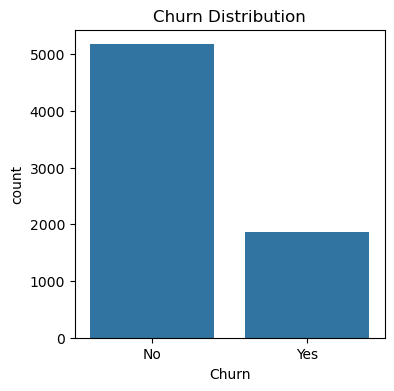

In [14]:
# CHurn Distribution

plt.figure(figsize=(4,4))
sns.countplot(x="Churn", data= data)
plt.title("Churn Distribution")
plt.show()

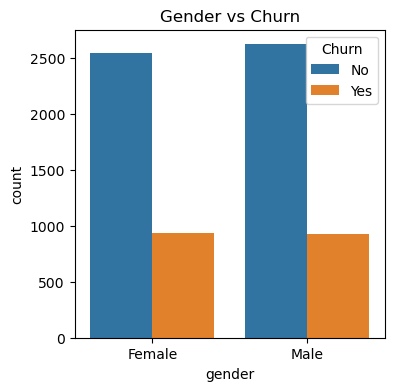

In [15]:
plt.figure(figsize=(4,4))
sns.countplot(x = "gender", hue = "Churn", data = data)
plt.title("Gender vs Churn")
plt.show()

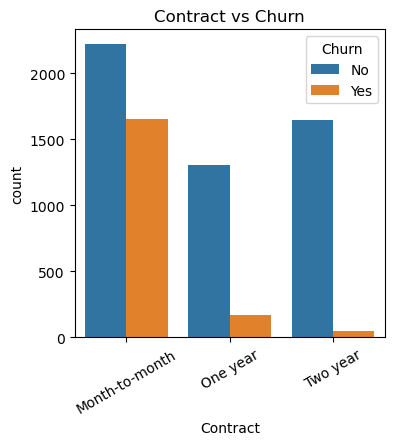

In [16]:
plt.figure(figsize=(4,4))
sns.countplot(x = "Contract", hue = "Churn", data = data)
plt.xticks(rotation = 30)
plt.title("Contract vs Churn")
plt.show()

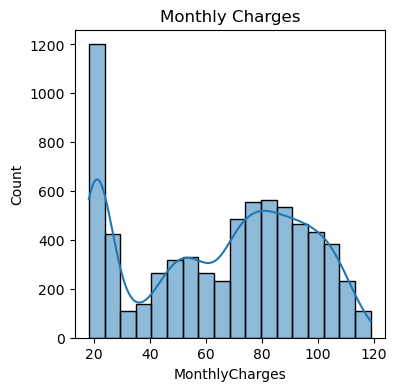

In [17]:
plt.figure(figsize=(4,4))
sns.histplot(data["MonthlyCharges"],kde = True)
plt.title("Monthly Charges")
plt.show()

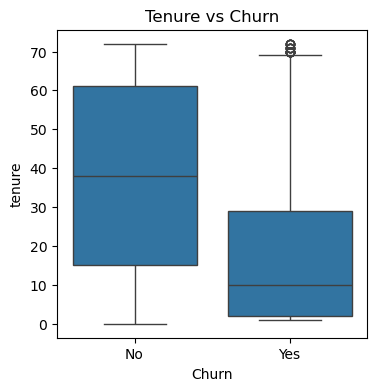

In [18]:
plt.figure(figsize=(4,4))
sns.boxplot(x="Churn", y="tenure", data=data)
plt.title("Tenure vs Churn")
plt.show()

In [19]:
le = LabelEncoder()

for column in data.columns:
    if data[column].dtype == "object":
        data[column] = le.fit_transform(data[column])


In [20]:
print("\nEncoded Dataset")
print(data.head())


Encoded Dataset
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1

In [21]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
lr_pred = lr.predict(X_test_scaled)

In [26]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
rf_pred = rf.predict(X_test)

In [28]:

# 11. XGBoost

!pip install xgboost
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [29]:
xgb_pred = xgb.predict(X_test)

In [30]:
def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_test, y_pred))

    print("Precision:", precision_score(y_test, y_pred))

    print("Recall   :", recall_score(y_test, y_pred))

    print("F1 Score :", f1_score(y_test, y_pred))

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))


In [31]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Random Forest", y_test, rf_pred)

evaluate_model("XGBoost", y_test, xgb_pred)

Logistic Regression
Accuracy : 0.815471965933286
Precision: 0.677115987460815
Recall   : 0.579088471849866
F1 Score : 0.6242774566473989

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409

Random Forest
Accuracy : 0.7955997161107168
Precision: 0.6591760299625468
Recall   : 0.4718498659517426
F1 Score : 0.55

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

XGBoost
Accuracy : 0.7920511000709723
Pre

In [32]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.815472   0.677116  0.579088  0.624277
1        Decision Tree  0.795600   0.659176  0.471850  0.550000
2        Random Forest  0.792051   0.630719  0.517426  0.568483


In [33]:
print(len(data))
print(len(lr_pred))

7043
1409


In [34]:
X_all = data.drop(["Churn"], axis=1)
X_all_scaled = scaler.transform(X_all)

In [35]:
# Logistic Regression
lr_prediction = lr.predict(X_all_scaled)

# Decision Tree
xgb_prediction = xgb.predict(X_all)

# Random Forest
rf_prediction = rf.predict(X_all)

In [36]:
data["LR_Prediction"] = lr_prediction
data["XGB_Prediction"] = xgb_prediction
data["RF_Prediction"] = rf_prediction

In [37]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LR_Prediction,XGB_Prediction,RF_Prediction
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,1,1,0
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,0,0,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,0,1,1
3,1,0,0,0,45,0,1,0,2,0,...,0,1,0,0,42.30,1840.75,0,0,0,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,2,70.70,151.65,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,...,2,1,1,3,84.80,1990.50,0,0,0,0
7039,0,0,1,1,72,1,2,1,0,2,...,2,1,1,1,103.20,7362.90,0,0,0,0
7040,0,0,1,1,11,0,1,0,2,0,...,0,0,1,2,29.60,346.45,0,0,0,0
7041,1,1,1,0,4,1,2,1,0,0,...,0,0,1,3,74.40,306.60,1,1,1,1


In [38]:
print(data["Churn"].unique())
print(data["LR_Prediction"].unique())
print(data["XGB_Prediction"].unique())
print(data["RF_Prediction"].unique())

[0 1]
[1 0]
[1 0]
[0 1]


In [43]:

data["Churn"] = data["Churn"].replace({0: "No", 1: "Yes"})
data["LR_Prediction"] = data["LR_Prediction"].replace({0: "No", 1: "Yes"})
data["XGB_Prediction"] = data["XGB_Prediction"].replace({0: "No", 1: "Yes"})
data["RF_Prediction"] = data["RF_Prediction"].replace({0: "No", 1: "Yes"})

In [44]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LR_Prediction,XGB_Prediction,RF_Prediction
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,No,Yes,Yes,No
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,No,No,No,No
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,Yes,No,Yes,Yes
3,1,0,0,0,45,0,1,0,2,0,...,0,1,0,0,42.30,1840.75,No,No,No,No
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,2,70.70,151.65,Yes,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,...,2,1,1,3,84.80,1990.50,No,No,No,No
7039,0,0,1,1,72,1,2,1,0,2,...,2,1,1,1,103.20,7362.90,No,No,No,No
7040,0,0,1,1,11,0,1,0,2,0,...,0,0,1,2,29.60,346.45,No,No,No,No
7041,1,1,1,0,4,1,2,1,0,0,...,0,0,1,3,74.40,306.60,Yes,Yes,Yes,Yes


In [46]:

models = ["Logistic Regression", "Random Forest", "XGBoost"]

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

print("\nModel Comparison")
print(comparison)




Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.815472
1        Random Forest  0.795600
2              XGBoost  0.792051


In [45]:
# Predict on New Customer

sample_customer = X.iloc[[0]]

prediction = xgb.predict(sample_customer)

if prediction[0] == 1:
    print("\nPrediction : Customer Will Churn")
else:
    print("\nPrediction : Customer Will Stay")


Prediction : Customer Will Churn


In [62]:
predictions_df = pd.DataFrame({
    "Gender": data["gender"].replace({0: "Female", 1: "Male"}),
    "SeniorCitizen": data["SeniorCitizen"],
    "Tenure": data["tenure"],
    "Actual_Churn": data["Churn"],
    "LR_Prediction": data["LR_Prediction"],
    "XGB_Prediction": data["XGB_Prediction"],
    "RF_Prediction": data["RF_Prediction"]
})

# Display the DataFrame
predictions_df.head()

,Gender,SeniorCitizen,Tenure,Actual_Churn,LR_Prediction,XGB_Prediction,RF_Prediction
0,Female,0,1,No,Yes,Yes,No
1,Male,0,34,No,No,No,No
2,Male,0,2,Yes,No,Yes,Yes
3,Male,0,45,No,No,No,No
4,Female,0,2,Yes,Yes,No,Yes


In [63]:
predictions_df.to_csv(r"C:\Users\akshay\Desktop\Customer_churn_prediction.csv", index = False)

In [64]:
import os

path = r"C:\Users\akshay\Desktop\Customer_churn_prediction.csv"   # Replace with your username
predictions_df.to_csv(path, index=False)

print("File exists:", os.path.exists(path))
print("Saved to:", path)

File exists: True
Saved to: C:\Users\akshay\Desktop\Customer_churn_prediction.csv


In [65]:
import os

print(os.path.expanduser("~/Desktop"))

C:\Users\akshay/Desktop


In [68]:
predictions_df.to_csv(r"C:\Users\akshay\Desktop\predictions_df.csv", index=False)

In [69]:
import os
print(os.path.abspath("predictions_df.csv"))

C:\Users\akshay\predictions_df.csv
